# Phase 4 — Concept Drift and Periodic Retraining

**Question.** Does a deployed fraud model degrade as time passes, and does
periodic retraining recover the loss?

**Protocol.** The series is cut into equal-duration time blocks and walked
forward. Before each block, a model is fitted under one of three deployment
policies:

| Policy | Training data |
|---|---|
| `static` | the warm-up period only, never updated |
| `expanding` | all history up to the current block |
| `sliding` | the most recent blocks only, deliberately forgetting older data |

Every fit uses rows that strictly precede the test block, so this asks *how
would this model have performed in production*, not *how well does it fit a
random sample*. The guarantee is enforced in `prequential_splits` and asserted
against real timestamps in `tests/test_drift.py`.

The model is held fixed at the final regularised XGBoost (no resampling;
parameters from `scripts/search_final_params.py`) so that what varies is the **retraining policy**, which
is the Phase 4 question.

## Scope caveat — read before quoting any number here

This dataset spans **48 hours**. Concept drift in the usual sense, fraud
tactics evolving over months, cannot be observed in two days. What is measured
is short-horizon temporal generalisation. The non-stationarity that does exist
is largely **diurnal**: volume and fraud rate swing with the day-night cycle.
That is prior-probability shift, not evolving fraud behaviour, and the write-up
should say so.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from fraud import config, drift, experiment  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

MODE_COLOR = {"static": "#C44E52", "expanding": "#4C72B0", "sliding": "#55A868"}
MODE_LABEL = {
    "static": "Static (never retrained)",
    "expanding": "Expanding window",
    "sliding": "Sliding window",
}

results = pd.read_csv(config.RESULTS_DIR / "drift_experiment.csv")
blocks_df = pd.read_csv(config.RESULTS_DIR / "drift_blocks.csv")
fdrift = pd.read_csv(config.RESULTS_DIR / "drift_features.csv")
print(f"{len(results)} runs, {results.test_block.nunique()} evaluated blocks, "
      f"{results.seed.nunique()} seeds")

60 runs, 4 evaluated blocks, 5 seeds


## 2. The temporal structure: what actually shifts

Before asking whether retraining helps, establish what is non-stationary at
all. Blocks are equal *duration* rather than equal count, deliberately: the
volume swing is part of the phenomenon and equal-count blocks would hide it.

In [2]:
print(blocks_df.to_string(index=False))

ratio = blocks_df.fraud_rate_pct.max() / blocks_df.fraud_rate_pct.min()
print(f"\nFraud rate spans {blocks_df.fraud_rate_pct.min():.3f}% to "
      f"{blocks_df.fraud_rate_pct.max():.3f}% -- a {ratio:.1f}x swing.")
print("Volume and fraud rate move in opposite directions: the quiet overnight")
print("blocks are the ones with the highest proportion of fraud.")

 block     n  n_fraud  fraud_rate_pct  start_hour  end_hour
     0 17482       81        0.463334    0.000000  7.999444
     1 60793      110        0.180942    7.999722 15.998611
     2 65959       81        0.122804   15.999444 23.998611
     3 17672       66        0.373472   23.999444 31.998056
     4 62116       59        0.094984   31.998889 39.997778
     5 59704       76        0.127295   39.998333 47.997778

Fraud rate spans 0.095% to 0.463% -- a 4.9x swing.
Volume and fraud rate move in opposite directions: the quiet overnight
blocks are the ones with the highest proportion of fraud.


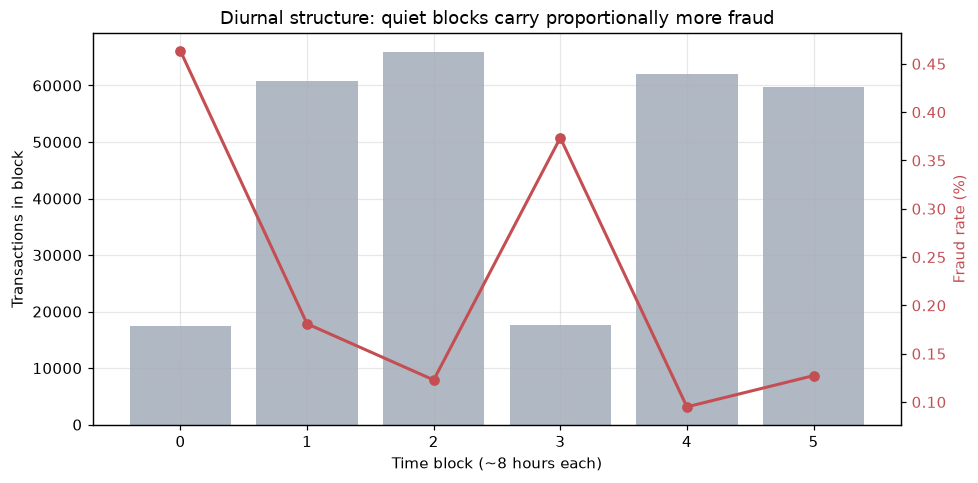

In [3]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = blocks_df.block
ax1.bar(x, blocks_df.n, color="#B0B8C4", label="Transactions")
ax1.set_xlabel("Time block (~8 hours each)")
ax1.set_ylabel("Transactions in block")
ax1.set_xticks(x)

ax2 = ax1.twinx()
ax2.plot(x, blocks_df.fraud_rate_pct, marker="o", color="#C44E52",
         linewidth=2, label="Fraud rate")
ax2.set_ylabel("Fraud rate (%)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.grid(False)

ax1.set_title("Diurnal structure: quiet blocks carry proportionally more fraud")
fig.tight_layout()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES_DIR / "phase4_block_structure.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Covariate shift

Two-sample KS statistics per feature against the reference block, computed on
legitimate transactions only so that prior shift does not contaminate the
covariate-shift measurement.

`Time` is excluded: blocks are *defined* by it, so its KS statistic would be
1.0 by construction — a tautology rather than a finding.

In [4]:
top = (fdrift.groupby("feature").ks_stat.max()
       .sort_values(ascending=False).head(10))
print("Largest KS statistic across blocks, by feature:\n")
for feat, stat in top.items():
    bar = "#" * int(stat * 40)
    print(f"  {feat:<8} {stat:.3f}  {bar}")

print("\nV12 and V14 are among the most fraud-discriminative components in")
print("this dataset, so the shift is not confined to harmless features.")

Largest KS statistic across blocks, by feature:

  V3       0.574  ######################
  V12      0.542  #####################
  V14      0.453  ##################
  V1       0.431  #################
  V9       0.399  ###############
  V13      0.360  ##############
  V28      0.360  ##############
  V11      0.354  ##############
  V25      0.316  ############
  V5       0.292  ###########

V12 and V14 are among the most fraud-discriminative components in
this dataset, so the shift is not confined to harmless features.


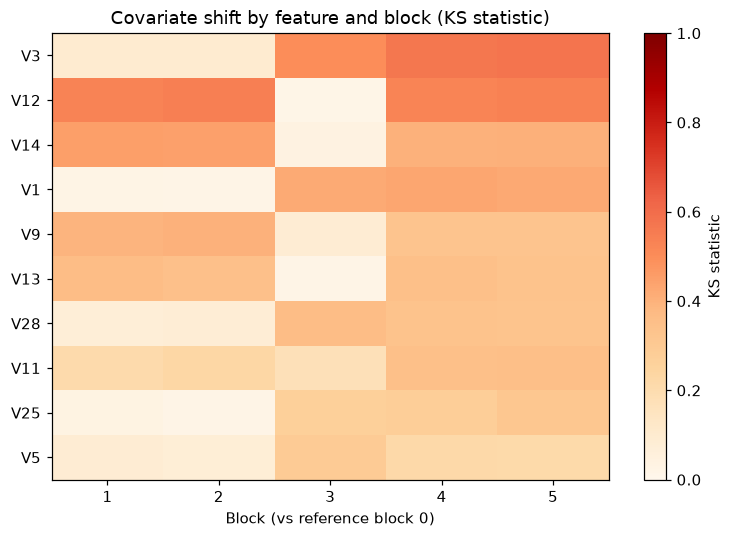

In [5]:
pivot = fdrift.pivot_table(index="feature", columns="block", values="ks_stat")
pivot = pivot.loc[top.index]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="OrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Block (vs reference block 0)")
ax.set_title("Covariate shift by feature and block (KS statistic)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="KS statistic")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase4_covariate_shift.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 3. Does the static model decay, and does retraining help?

The first evaluated block is a **correctness check, not a comparison**: all
three policies train on the identical warm-up there, so they must agree
exactly. Any spread would mean the splits are wired wrong.

In [6]:
per_block = results.groupby(["mode", "test_block"]).pr_auc.mean().unstack("mode")
print("Mean PR-AUC per block (averaged over seeds):\n")
print(per_block.round(4).to_string())

first = per_block.index.min()
spread = per_block.loc[first].max() - per_block.loc[first].min()
print(f"\nSanity check -- block {first} spread across policies: {spread:.6f}")
print("(all policies share one training set there, so this must be ~0)")

Mean PR-AUC per block (averaged over seeds):

mode        expanding  sliding  static
test_block                            
2              0.7910   0.7910  0.7910
3              0.8047   0.7833  0.8106
4              0.7773   0.7617  0.7477
5              0.8038   0.8013  0.7822

Sanity check -- block 2 spread across policies: 0.000000
(all policies share one training set there, so this must be ~0)


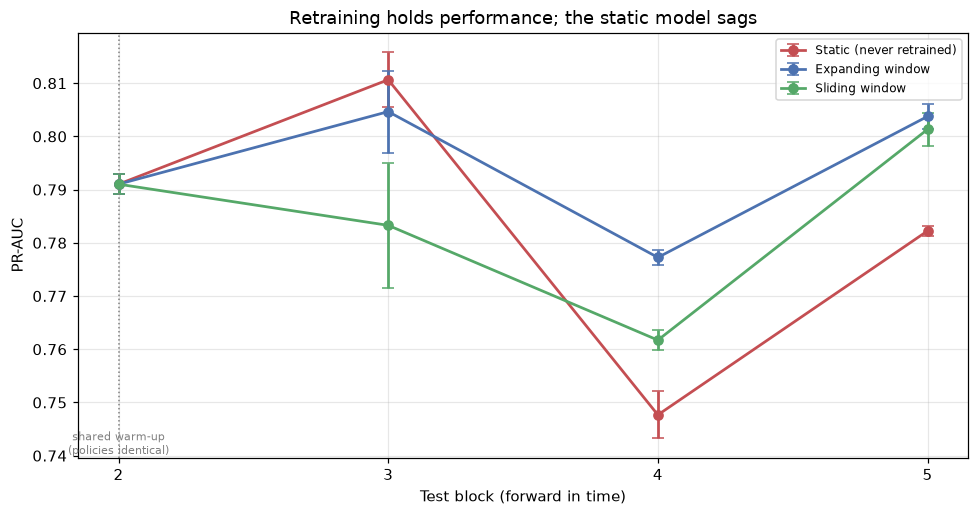

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for mode in ["static", "expanding", "sliding"]:
    grp = results[results["mode"] == mode].groupby("test_block").pr_auc
    ax.errorbar(grp.mean().index, grp.mean().values, yerr=grp.std().values,
                marker="o", capsize=4, linewidth=1.8,
                color=MODE_COLOR[mode], label=MODE_LABEL[mode])
ax.axvline(per_block.index.min(), color="grey", linestyle=":", linewidth=1)
ax.annotate("shared warm-up\n(policies identical)",
            (per_block.index.min(), ax.get_ylim()[0]), fontsize=7,
            ha="center", va="bottom", color="grey")
ax.set_xlabel("Test block (forward in time)")
ax.set_ylabel("PR-AUC")
ax.set_xticks(sorted(results.test_block.unique()))
ax.set_title("Retraining holds performance; the static model sags")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase4_retraining_over_time.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Paired comparison

With only a handful of evaluated blocks, an average can be dominated by one
block. The honest test is paired and per-block: does retraining win *each
time*, and by how much?

In [8]:
base = per_block["static"].drop(index=first)
for mode in ["expanding", "sliding"]:
    delta = per_block[mode].drop(index=first) - base
    print(f"{MODE_LABEL[mode]:<28} mean {delta.mean():+.4f}   "
          f"wins {int((delta > 0).sum())}/{len(delta)}   "
          f"per block: {', '.join(f'{v:+.3f}' for v in delta)}")
print(f"\nn = {len(base)} blocks at this blocking. Direction and effect size")
print("are reportable; a p-value on three points would not be.")

Expanding window             mean +0.0150   wins 2/3   per block: -0.006, +0.030, +0.022
Sliding window               mean +0.0019   wins 2/3   per block: -0.027, +0.014, +0.019

n = 3 blocks at this blocking. Direction and effect size
are reportable; a p-value on three points would not be.


## 4. Sensitivity: does the conclusion survive a different blocking?

A single choice of block count is an arbitrary analyst decision, so the same
experiment was repeated at 8 and 12 blocks. If retraining only won at one
blocking, the result would be an artefact.

In [9]:
rows = []
for n_blocks, path in [
    (6, "drift_experiment.csv"),
    (8, "drift_experiment_8blocks.csv"),
    (12, "drift_experiment_12blocks.csv"),
]:
    full = config.RESULTS_DIR / path
    if not full.exists():
        continue
    r = pd.read_csv(full)
    pb = r.groupby(["mode", "test_block"]).pr_auc.mean().unstack("mode")
    pb = pb.drop(index=pb.index.min())
    for mode in ["expanding", "sliding"]:
        d = pb[mode] - pb["static"]
        rows.append({
            "n_blocks": n_blocks,
            "block_hours": round(48 / n_blocks, 1),
            "mode": mode,
            "mean_delta": d.mean(),
            "wins": f"{int((d > 0).sum())}/{len(d)}",
            "n_test_blocks": len(d),
        })
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

 n_blocks  block_hours      mode  mean_delta wins  n_test_blocks
        6          8.0 expanding    0.015037  2/3              3
        6          8.0   sliding    0.001921  2/3              3
        8          6.0 expanding    0.024164  5/5              5
        8          6.0   sliding    0.010244  4/5              5
       12          4.0 expanding    0.038459  7/9              9
       12          4.0   sliding    0.030428  7/9              9


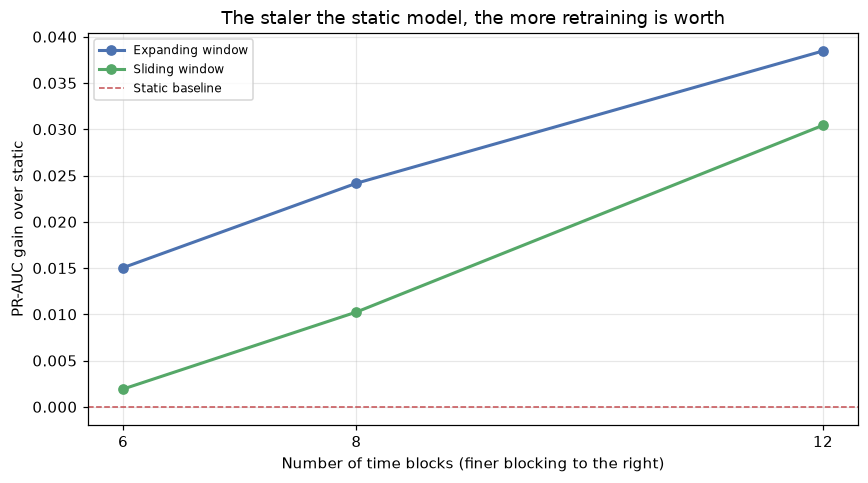

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for mode in ["expanding", "sliding"]:
    s = sens[sens["mode"] == mode]
    ax.plot(s.n_blocks, s.mean_delta, marker="o", linewidth=2,
            color=MODE_COLOR[mode], label=MODE_LABEL[mode])
ax.axhline(0, color="#C44E52", linestyle="--", linewidth=1,
           label="Static baseline")
ax.set_xticks(sens.n_blocks.unique())
ax.set_xlabel("Number of time blocks (finer blocking to the right)")
ax.set_ylabel("PR-AUC gain over static")
ax.set_title("The staler the static model, the more retraining is worth")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase4_retraining_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Findings

These findings use the **regularised** final model. The first version of this
analysis used the Phase 3 parameters, which overfit their training data
(training PR-AUC 0.9995 against 0.795 on test). Regularising the model changed
the results below materially, and the change is itself the most informative
thing this phase found.

**1. Retraining still beats a static model on average — 14 of 17 blocks.**
Pooling the three blockings, the expanding window beats static in 14 of 17
evaluated blocks and the sliding window in 13. Before regularisation both
figures were higher (17 and 16). The direction holds; the margin does not.

**2. Part of the apparent benefit of retraining was compensation for
overfitting.** The advantage over static roughly halved after regularisation —
from +0.022, +0.062 and +0.086 to +0.015, +0.024 and +0.038 at 6, 8 and 12
blocks. The retrained models barely changed; the static model improved
substantially (at 12 blocks, from 0.695 to 0.742 mean PR-AUC). An overfitted
model memorises its training period and decays on later data, and retraining
had been rescuing it from that. A model that does not overfit holds up far
better over time on its own, so there is less for retraining to recover.

**3. The advantage still grows the staler the static model gets.** +0.015,
+0.024, +0.038 across the three blockings: the finer the blocking, the longer
the static model's warm-up sits behind the test period. That gradient remains
the clearest evidence of decay with time since training — now measured
without overfitting inflating it.

**4. Expanding still beats sliding, so the benefit is more data, not
forgetting.** By +0.013, +0.014 and +0.008 on average. If fraud patterns were
genuinely evolving, discarding stale data would help and sliding would win. It
does not.

**5. What shifts is the prior and the covariates, diurnally.** Fraud rate
swings about fivefold between blocks (4.9×), and several PCA components show
substantial covariate shift. The shift is real; its cause is the day-night
cycle rather than adversarial adaptation.

### Limitations

The 48-hour span is the binding constraint. Everything above is short-horizon
temporal generalisation, and finding 4 would need a multi-month series to test
properly — on this data, absence of evidence for concept drift is weak
evidence of absence.

Finding 2 is a warning that applies well beyond this dataset: drift studies
that retrain an overfitted model can overstate the value of retraining.

The finer blockings buy more test blocks at the cost of fewer frauds in each
(as few as 21 at 12 blocks), so per-block PR-AUC is noisiest exactly where the
comparison count is highest. That is why all three blockings are reported.

This phase compares retraining policies for XGBoost only. The neural network
and the other models were evaluated elsewhere in the project but are not part
of the drift experiment.